In [1]:
# Import necessary libraries for data processing and visualization
import os
import lzma
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.utils.class_weight import compute_class_weight
from rdkit import Chem
from rdkit.Chem.rdMolDescriptors import CalcMolFormula
from bioservices import KEGG, ChEBI

import ssefcca_functions as sfc

# to disable invalid SMILES warnings:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

## Create CSV from Laszakovitz and MacKay (2022)

In [2]:
# Define folder paths for input data and output files
data_folder = 'data/csv_files/molec_db'  # Molecular database CSV files

save_csvs_folder = 'data/csv_files'  # Output location for processed CSV files
save_plots_folder = 'data/plots/van_krevelens'  # Output location for Van Krevelen plots

In [3]:
# Get list of all L&M (Laszakovits and MacKay) CSV files from the data folder
LM_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and 'l&m' in x]

In [ ]:
# Functions

def get_elements_from_formula(formula) -> dict:
    '''
    Parse a molecular formula string and extract element counts.
    
    Args:
        formula (str): Molecular formula (e.g., 'C6H12O6')
    
    Returns:
        dict: Dictionary mapping element symbols to their counts
              (e.g., {'C': 6, 'H': 12, 'O': 6})
    '''
    elements = {}
    current_element = ''
    current_count = ''
    
    for char in formula:
        if char.isupper():
            # Save previous element if exists
            if current_element:
                elements[current_element] = int(current_count) if current_count else 1
            current_element = char
            current_count = ''
        elif char.islower():
            # Add to current element (e.g., 'C' + 'l' = 'Cl')
            current_element += char
        elif char.isdigit():
            # Build the count number
            current_count += char
    
    # Add the last element
    if current_element:
        elements[current_element] = int(current_count) if current_count else 1
    
    return elements


def get_peptide_formula(sequence, amino_acids_dict) -> dict:
    '''
    Calculate the total elemental composition of a peptide from its sequence.
    
    Args:
        sequence (str): Peptide sequence using single-letter amino acid codes (e.g., 'ACDEFG')
        amino_acids_dict (dict): Dictionary mapping amino acid codes to their elemental compositions
    
    Returns:
        dict: Total elemental composition of the peptide
              (e.g., {'C': 24, 'H': 40, 'O': 8, 'N': 6})
    '''
    total_elements = {}
    
    # Sum up elements from each amino acid in the sequence
    for aa in sequence:
        aa_elements = amino_acids_dict.get(aa, {})
        for element, count in aa_elements.items():
            total_elements[element] = total_elements.get(element, 0) + count
    
    return total_elements


def annotate_aa_plot(text, df, ax, xytext):
    '''
    Add an annotation with an arrow to a matplotlib axis for amino acid plots.
    
    Args:
        text (str): Label text (amino acid name)
        df (pd.DataFrame): DataFrame containing O/C and H/C ratios, indexed by amino acid names
        ax (matplotlib.axes.Axes): Matplotlib axis object to add annotation to
        xytext (tuple): (x, y) coordinates for the text label position
    '''
    ax.annotate(text, fontsize=14,
                xy=(df.loc[text]['O/C'], df.loc[text]['H/C']),
                xytext=xytext, arrowprops=dict(arrowstyle='-'),
                horizontalalignment='center', verticalalignment='bottom')


def add_weights_col(df,col='category'):
    class_weights = compute_class_weight('balanced', classes=np.unique(df[col]), y=df[col])
    weights_dict = {cls: weight for cls, weight in zip(np.unique(df[col]), class_weights)}

    # Add weights column to dataframe
    df['weights'] = [weights_dict[cat] for cat in df[col]]


def smiles2form(smiles):
    try:
        return CalcMolFormula(Chem.MolFromSmiles(smiles))
    except:
        return np.nan


def categories_summary(df:pd.DataFrame,col:str,dec_places=2):
    value_counts = df[col].value_counts()
    tot = value_counts.sum()
    for cat in value_counts.index:
        print(f'{cat}: {value_counts[cat]} ({np.round(100*value_counts[cat]/tot,dec_places)}%)')
    print(f'tot: {tot}')

In [5]:
# Process L&M (Lipids & Metabolites) Files
# Build a comprehensive dataframe with elemental compositions and ratios

lm_df = pd.DataFrame()
amino_acids_dict = {}  # Store amino acid elemental compositions for peptide calculations

for file in LM_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)

    # Extract category name from filename
    category = file.replace('.csv', '').replace('l&m-', '')

    # Special handling for amino acids - store their compositions for peptide calculations
    if category == 'amino_acid':
        for letter in df['1-letter code']:
            amino_acids_dict[letter] = get_elements_from_formula(df['FORMULA'][df['1-letter code'] == letter].to_list()[0])
        
        # Amino acids will be grouped under 'peptide' category
        category = 'peptide'
    
    # Initialize dataframe slice for this category
    df_slice = pd.DataFrame({'category': [category] * len(df)})
    atomic_dict = {'C': [], 'H': [], 'O': [], 'N': [], 'S': [], 'P': []}

    try:
        # Try to get formula directly from the dataframe
        df_slice['formula'] = df['FORMULA']

    except KeyError:
        # Handle special cases where formula needs to be calculated
        if category == 'peptide':
            # Calculate formulas from peptide sequences
            seqs = df['Sequence'].to_list()
            peptides_formula_dict_list = [get_peptide_formula(seq, amino_acids_dict) for seq in seqs]

            df_slice['formula'] = [''.join([f'{x}{formula_dict[x]}' for x in formula_dict]) for formula_dict in peptides_formula_dict_list]

        elif category == 'lignin':
            # Lignin data has individual element columns instead of formulas
            for element in atomic_dict.keys():
                if element in df.columns:
                    atomic_dict[element] = df[element].to_list()
                else:
                    atomic_dict[element] = [0] * len(df)
    
    # Parse formulas into individual element counts (skip for lignin as already done)
    if category != 'lignin':
        for formula in df_slice['formula']:
            elements = get_elements_from_formula(formula)
            for element in atomic_dict.keys():
                atomic_dict[element].append(elements.get(element, 0))
    
    # Convert atomic counts to dataframe and combine with category info
    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)

    if category == 'peptide':
        # Add water to peptide formulas
        df_slice['H'] += 2
        df_slice['O'] += 1
    
    # Append to overall dataframe
    if len(lm_df) == 0:
        lm_df = df_slice
    else:
        lm_df = pd.concat([lm_df, df_slice], ignore_index=True)

# Calculate elemental ratios (normalized to carbon)
for element in atomic_dict.keys():
    if element != 'C':
        lm_df[f'{element}/C'] = lm_df[element] / lm_df['C']

# Calculate N/P ratio (important for nutrient analysis)
lm_df['N/P'] = lm_df['N'] / lm_df['P']

In [6]:
# Sort by category for better organization
lm_df = lm_df.sort_values(by=['category']).reset_index(drop=True)

# Display category distribution and sort the dataframe
print(lm_df['category'].value_counts())

category
lipid           5109
lignin           297
peptide          263
tannin           192
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


In [7]:
# Compute class weights to handle imbalanced dataset
# This gives higher weight to underrepresented categories during model training

add_weights_col(lm_df)

In [8]:
# Save the processed dataframe (without PAHs)
lm_df.to_csv(f'{save_csvs_folder}/l&m_combined.csv', index=False)

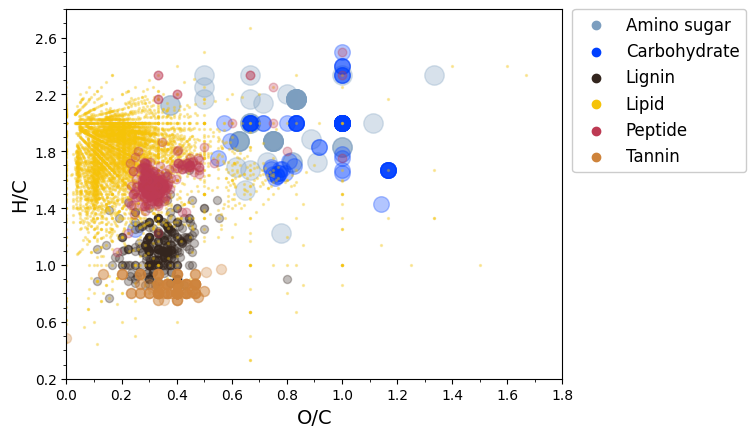

In [9]:
# Create Van Krevelen Diagram
# Van Krevelen diagrams show O/C vs H/C ratios to visualize molecular composition

fig, ax = plt.subplots()

# Plot each category with different colors
# Point size is inversely proportional to category size (more visible for smaller categories)
for category in lm_df['category'].unique():
    subset = lm_df[lm_df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'],
               c=sfc.vk_region_colours[category],
               alpha=0.3, s=1e4/len(lm_df[lm_df['category'] == category]))

# Create legend with proper labels
for cat in lm_df['category'].unique():
    ax.scatter(None, None, c=sfc.vk_region_colours[cat],
               label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH')

# Set axis labels and formatting
ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)

sfc.set_axis_ticks(lm_df['O/C'].values, ax, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
sfc.set_axis_ticks(lm_df['H/C'].values, ax, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

ax.legend(framealpha=1, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12)
fig.savefig(f'{save_plots_folder}/vk_diagram.svg', dpi=600, facecolor='#fff', bbox_inches='tight')


## Include more formulae
For carbohydrates, lignins, and tannins, the L&M ones will be used as there are more formulae than those used by Rivas Ubach *et al.* (2018)

### Lipids

In [11]:
# get all lipid formulae on the LIPID MAPS database as of 09/07/2026

lipidmaps = pd.read_csv(f'{data_folder}/lipidmaps_ids_cc0.tsv',sep='\t')
# remove polyketides
lipidmaps = lipidmaps[['PK' not in x for x in lipidmaps['lm_id']]].reset_index()

lipidmaps = lipidmaps.drop(columns=['lm_id','inchi_key','obsolete_id'])

print(f'Number of lipids: {len(lipidmaps)}')

# clean up SMILES NAs
lipidmaps = lipidmaps[~lipidmaps['smiles'].isna()]
print(f'Number of lipids after removing those without SMILES: {len(lipidmaps)}')

# clean up duplicated smiles
lipidmaps = pd.DataFrame(lipidmaps['smiles'].unique(),columns=['smiles'])

print(f'Number of lipids after removing duplicate SMILES: {len(lipidmaps)}')


# go from SMILES to molecular formula discarding wrong SMILES
lipidmaps['formula'] = [smiles2form(x) for x in lipidmaps['smiles']]
lipidmaps = lipidmaps[~lipidmaps['formula'].isna()]

print(f'Number of lipids after removing those without valid SMILES: {len(lipidmaps)}')

lipidmaps.insert(0,'category',['lipid']*len(lipidmaps))

# remove smiles column 
lipidmaps = lipidmaps.drop(columns=['smiles'])
lipidmaps.reset_index(inplace=True,drop=True)

# get stoichiometry
lipidmaps = pd.concat((lipidmaps,pd.DataFrame([get_elements_from_formula(x) for x in lipidmaps['formula']])),axis=1)

# remove formulae with rare heteroatoms
heteros = ['F','Br','As','Cl','I','Si','Fe',]
for h in heteros:
    lipidmaps = lipidmaps[lipidmaps[h].isna()]
lipidmaps=lipidmaps.drop(columns=heteros)

print(f'Number of lipids after removing those with {', '.join(heteros)}: {len(lipidmaps)}')


Number of lipids: 43499
Number of lipids after removing those without SMILES: 42924
Number of lipids after removing duplicate SMILES: 42499
Number of lipids after removing those without valid SMILES: 42496
Number of lipids after removing those with F, Br, As, Cl, I, Si, Fe: 42036


### Peptides

In [12]:
# get all sequences in FASTA format for all entries in the PDB archive as of 09/07/2026
# load file
with lzma.open(f'{data_folder}/pdb_seqres.txt.xz', 'rt') as f:
    pdb_seq = f.read()
# split it by row
pdb_seq = pdb_seq.split('\n>')
f.close()
# filter only for proteins (no DNA or other)
pdb_seq = [x for x in pdb_seq if 'mol:protein' in x]
# get the FASTA code
pdb_seq = [x.split('\n')[-1] for x in pdb_seq]

print(f'Total peptide sequences in the PDB archive: {len(pdb_seq)}')

# get unique sequences
# using np.unique results in too much memory being used
pdb_seq.sort()
pdb_seq2 = []
for seq in pdb_seq:
    if len(pdb_seq2)>0:
        if seq != pdb_seq2[-1] and seq != '':
            pdb_seq2.append(seq)
    else:
        if seq != '':
            pdb_seq2.append(seq)

pdb_seq = pdb_seq2.copy()
del pdb_seq2 # for memory efficiency
print(f'Total unique peptide sequences in the PDB archive: {len(pdb_seq)}')

# remove formulae with X (indicating any amino acid)
pdb_seq = [x for x in pdb_seq if 'X' not in x]
print(f'Total unique peptide sequences in the PDB archive without unknown ("X") amino acids: {len(pdb_seq)}')

Total peptide sequences in the PDB archive: 1073492
Total unique peptide sequences in the PDB archive: 183999
Total unique peptide sequences in the PDB archive without unknown ("X") amino acids: 178391


In [13]:
# make a pandas df with formulae and stoichiometries 
peptides_formula_dict_list = [get_peptide_formula(x,amino_acids_dict) for x in pdb_seq]
seq_formulae = [''.join([f'{x}{formula_dict[x]}' for x in formula_dict]) for formula_dict in peptides_formula_dict_list]

pdb_df = pd.DataFrame()
pdb_df['category'] = ['peptide']*len(seq_formulae)
pdb_df['formula'] = seq_formulae

pdb_df = pd.concat((pdb_df,pd.DataFrame(peptides_formula_dict_list)),axis=1)

# amino acids df
aa_forms = [''.join([f'{x}{amino_acids_dict[aa][x]}' for x in amino_acids_dict[aa]]) for aa in amino_acids_dict]
aa_df = pd.DataFrame()
aa_df['category'] = ['peptide']*len(aa_forms)
aa_df['formula'] = aa_forms
aa_df = pd.concat((aa_df,pd.DataFrame(amino_acids_dict).T.reset_index(drop=True)),axis=1)

# combine
pept_df = pd.concat((aa_df,pdb_df))

# Add water
pept_df['H'] += 2
pept_df['O'] += 1

### Amino sugars

In [14]:
# amino sugars taken from KEGG and ChEBI 10/07/2026
asugar_db = pd.read_csv(f'{data_folder}/amino_sugars.csv')

asugar_form = []

kegg = KEGG(verbose=False)
chebi = ChEBI(verbose=False)

for row in asugar_db.to_numpy():
    if row[2] == 'KEGG':
        cpd = kegg.get(f'cpd:{row[0]}').split('\n')
        for info in cpd:
            if 'FORMULA' in info:
                asugar_form.append(info.replace(' ','').replace('FORMULA',''))
                break

    elif row[2] == 'ChEBI':
        try:
            cpd = chebi.getCompleteEntity(f'CHEBI:{row[0]}')['chemical_data']['formula']
            asugar_form.append(cpd)
        # in case the molecular formula isn't available but the SMILES is
        except TypeError:
            cpd = chebi.getCompleteEntity(f'CHEBI:{row[0]}')['default_structure']['smiles']
            asugar_form.append(smiles2form(cpd.replace('*','')))

asugar_form = [x for x in asugar_form if 'R' not in x]

# remove formulae with "R" groups
asugar_form = [x for x in asugar_form if 'R' not in x]

# make the df
asugar_df = pd.DataFrame()

asugar_df['category'] = ['amino_sugar']*len(asugar_form)
asugar_df['formula'] = asugar_form
asugar_df = pd.concat((asugar_df,pd.DataFrame([get_elements_from_formula(x) for x in asugar_form])),axis=1)

print(f'Number of amino sugar formulae found: {len(asugar_df)}')

Number of amino sugar formulae found: 85


### Combine

In [15]:
dbs_concat = pd.concat((lipidmaps,pept_df,asugar_df))

# elemental ratios
dbs_concat = dbs_concat.replace(np.nan, 0)
for element in atomic_dict.keys():
    if element != 'C':
        dbs_concat[f'{element}/C'] = dbs_concat[element] / dbs_concat['C']

dbs_concat['N/P'] = dbs_concat['N'] / dbs_concat['P']

In [16]:
lm_df_slice = lm_df[[x in ['lignin','tannin','carbohydrate'] for x in lm_df['category']]]

overall_df = pd.concat((lm_df_slice,dbs_concat))
overall_df = overall_df.sort_values(by=['category']).reset_index(drop=True)

# recalculate weights
add_weights_col(overall_df)
# save
overall_df.to_csv(f'{save_csvs_folder}/new_vk_areas_df.csv', index=False)

In [32]:
categories_summary(overall_df,'category')

peptide: 178411 (80.69%)
lipid: 42036 (19.01%)
lignin: 297 (0.13%)
tannin: 192 (0.09%)
amino_sugar: 85 (0.04%)
carbohydrate: 79 (0.04%)
tot: 221100


# Create a CSV file to include PAHs as well 

In [33]:
# Get all remaining CSV files (including PAHs) that weren't in the L&M set
pah_df = pd.read_csv(f'{data_folder}/pah.csv')
pah_df.insert(0,'category',['pah']*len(pah_df))
pah_df = pah_df.drop(columns=['name'])

pah_df = pd.concat((pah_df,pd.DataFrame([get_elements_from_formula(x) for x in pah_df['formula']])),axis=1)

if 'P' not in pah_df:
    pah_df['P']=[np.nan]*len(pah_df)

# elemental ratios
pah_df = pah_df.replace(np.nan, 0)
for element in atomic_dict.keys():
    if element != 'C':
        pah_df[f'{element}/C'] = pah_df[element] / pah_df['C']

pah_df['N/P'] = pah_df['N'] / pah_df['P']

In [34]:
overall_df_with_pahs = pd.concat((overall_df,pah_df))
overall_df_with_pahs = overall_df_with_pahs.sort_values(by=['category']).reset_index(drop=True)
add_weights_col(overall_df_with_pahs)
overall_df_with_pahs.to_csv(f'{save_csvs_folder}/new_vk_areas_with_pahs.csv', index=False)

In [43]:
categories_summary(overall_df_with_pahs,'category')

peptide: 178411 (80.66%)
lipid: 42036 (19.0%)
lignin: 297 (0.13%)
tannin: 192 (0.09%)
pah: 86 (0.04%)
amino_sugar: 85 (0.04%)
carbohydrate: 79 (0.04%)
tot: 221186


## Some summary plots

Text(0.5, 1.0, 'Atomic Ratios Distributions')

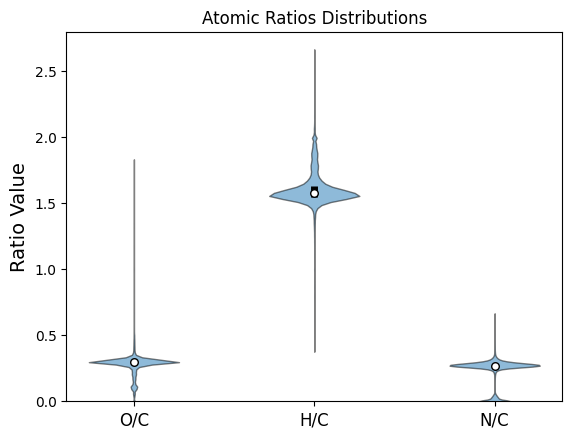

In [35]:
fig, ax = plt.subplots()

violin_plot_labels = ['O/C','H/C','N/C']
violin_plot_data = [overall_df_with_pahs[x].tolist() for x in violin_plot_labels]

parts = ax.violinplot(violin_plot_data,
                      showmeans=False, showmedians=False,
                      showextrema=False)
for pc in parts['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(.5)
quartile1, medians, quartile3 = np.percentile(np.array(violin_plot_data), [25, 50, 75], axis=1)

inds = np.arange(1, len(medians) + 1)
ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3, edgecolors='k')
ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

ax.set_ylabel('Ratio Value', fontsize=14)
ax.set_xticks(np.arange(1, len(violin_plot_labels) + 1), violin_plot_labels, fontsize=12)

ax.set_ylim(0)

ax.set_title('Atomic Ratios Distributions')

### vK

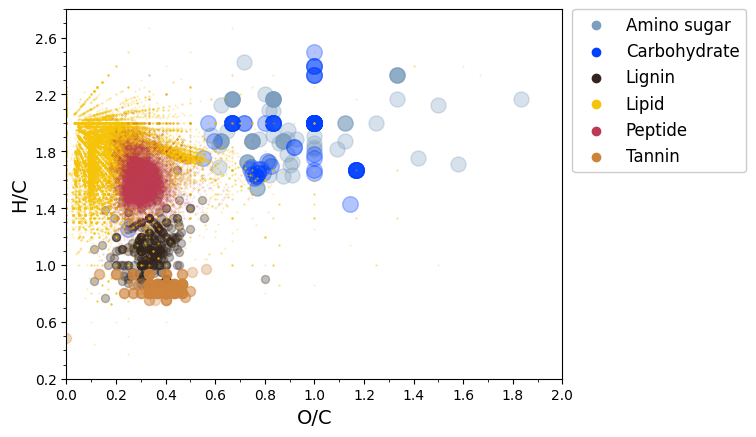

In [36]:
# Create Van Krevelen Diagram
# Van Krevelen diagrams show O/C vs H/C ratios to visualize molecular composition

fig, ax = plt.subplots()

# Plot each category with different colors
# Point size is inversely proportional to category size (more visible for smaller categories)
for category in overall_df['category'].unique():
    subset = overall_df[overall_df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'],
               c=sfc.vk_region_colours[category],
               alpha=0.3, s=1e4/len(overall_df[overall_df['category'] == category]))

# Create legend with proper labels
for cat in overall_df['category'].unique():
    ax.scatter(None, None, c=sfc.vk_region_colours[cat],
               label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH')

# Set axis labels and formatting
ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)

sfc.set_axis_ticks(overall_df['O/C'].values, ax, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
sfc.set_axis_ticks(overall_df['H/C'].values, ax, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

ax.legend(framealpha=1, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12)
fig.savefig(f'{save_plots_folder}/vk_diagram.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

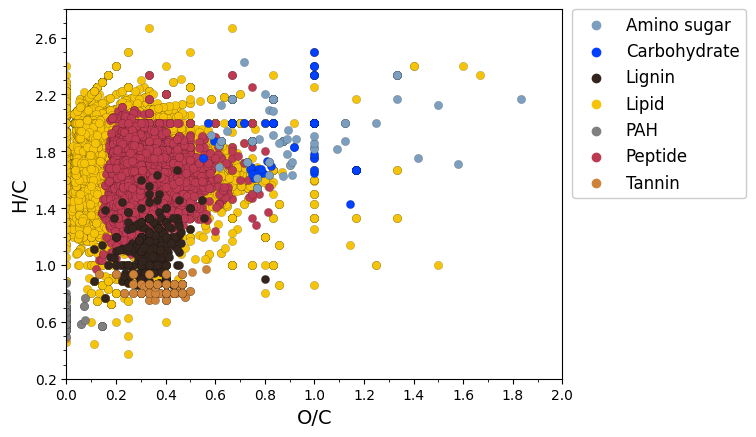

In [37]:
# Create Van Krevelen Diagram with PAHs (2D)

fig, ax_2d = plt.subplots()

# Plot each category with distinct colors
for category in ['lipid', 'peptide', 'carbohydrate', 'amino_sugar', 'lignin', 'tannin', 'pah']:
    subset = overall_df_with_pahs[overall_df_with_pahs['category'] == category]
    ax_2d.scatter(subset['O/C'], subset['H/C'],
                  c=sfc.vk_region_colours[category],
                  edgecolor='k', lw=.1)
    
# Create legend
for cat in overall_df_with_pahs['category'].unique():
    ax_2d.scatter(None, None, c=sfc.vk_region_colours[cat],
                  label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH')

# Format axes
ax_2d.set_xlabel('O/C', fontsize=14)
ax_2d.set_ylabel('H/C', fontsize=14)

sfc.set_axis_ticks(overall_df_with_pahs['O/C'].values, ax_2d, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
sfc.set_axis_ticks(overall_df_with_pahs['H/C'].values, ax_2d, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

ax_2d.legend(framealpha=1, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12)
fig.savefig(f'{save_plots_folder}/vk_diagram_with_pahs.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

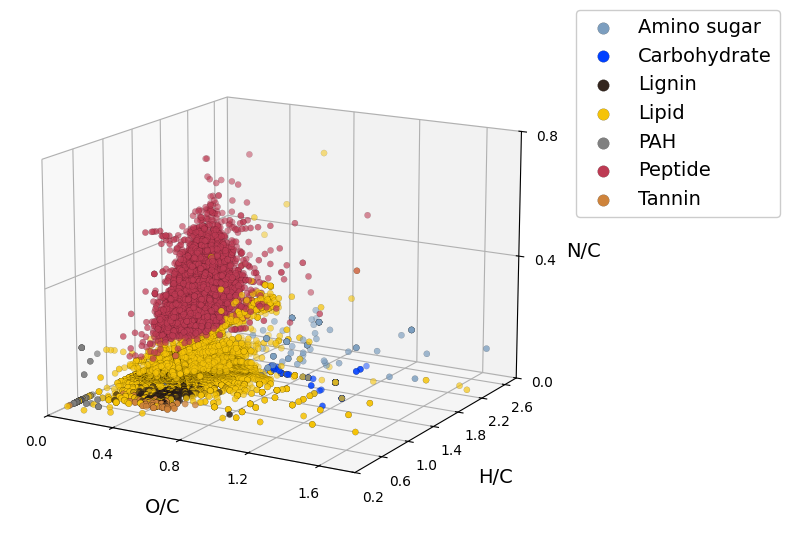

In [38]:
# Create 3D Van Krevelen Diagram with PAHs
# Third dimension (N/C) provides additional chemical space information

fig = plt.figure(figsize=(12, 7))  # width, height

ax_3d = fig.add_subplot(111, projection='3d')

# Plot all data points colored by category
ax_3d.scatter(overall_df_with_pahs['O/C'], overall_df_with_pahs['H/C'], overall_df_with_pahs['N/C'],
              c=[sfc.vk_region_colours[cat] for cat in overall_df_with_pahs['category']],
              edgecolor='k', lw=.1)

# Set axis ranges and ticks
sfc.set_axis_ticks(overall_df_with_pahs['O/C'], ax_3d, axis='x', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, 1.8), upper_lim=max(0, 1.8))
sfc.set_axis_ticks(overall_df_with_pahs['H/C'], ax_3d, axis='y', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(.2, 2.8), upper_lim=max(.2, 2.8))
sfc.set_axis_ticks(overall_df_with_pahs['N/C'], ax_3d, axis='z', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, .8), upper_lim=max(0, .8))

# Create legend (plotted outside visible range so only labels show)
for cat in overall_df_with_pahs['category'].unique():
    ax_3d.scatter(10, 10, 10, c=sfc.vk_region_colours[cat], alpha=1, edgecolor='k', lw=.1,
                  label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH',
                  s=70)
    
ax_3d.legend(framealpha=1, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=14)
ax_3d.view_init(elev=15, azim=-60)

# Label axes
ax_3d.set_xlabel('O/C', fontsize=14, labelpad=15)
ax_3d.set_ylabel('H/C', fontsize=14, labelpad=15)
ax_3d.set_zlabel('N/C', fontsize=14, labelpad=8)

fig.savefig(f'{save_plots_folder}/vk_diagram_with_pahs_3d.png', dpi=600, facecolor='#fff', bbox_inches='tight')

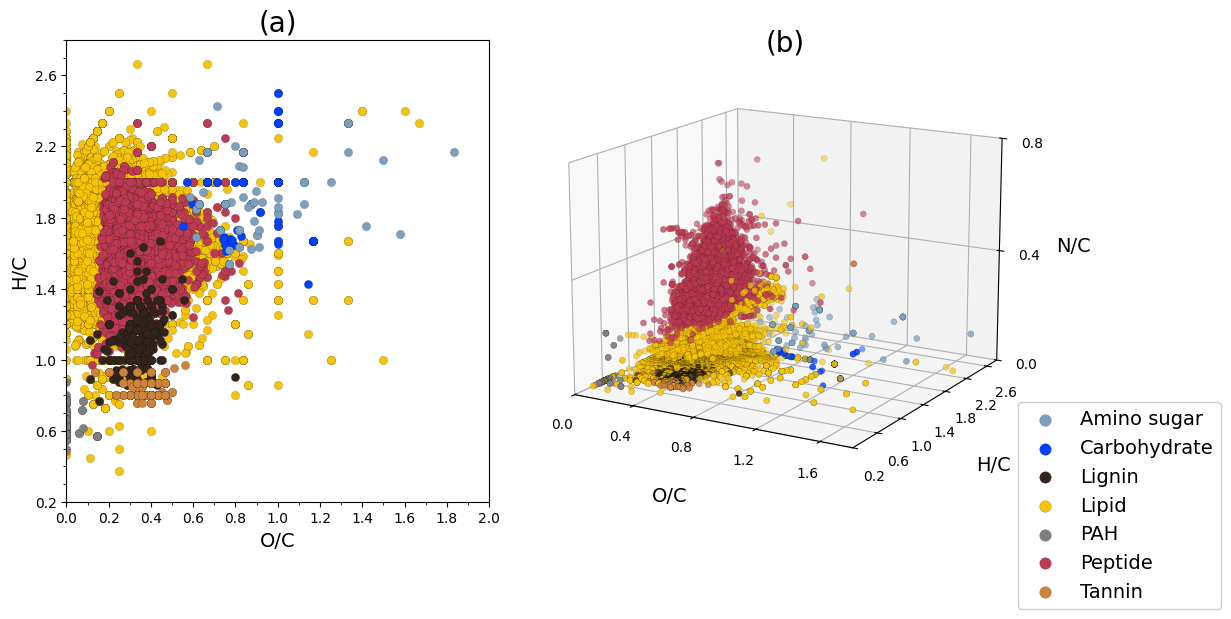

In [39]:
# Create Combined 2D and 3D Van Krevelen Diagram with PAHs
# Side-by-side comparison showing both perspectives

fig = plt.figure(figsize=(12, 6))

# 2D Plot (subplot a)
ax_2d = fig.add_subplot(121)

for category in ['lipid', 'peptide', 'carbohydrate', 'amino_sugar', 'lignin', 'tannin', 'pah']:
    subset = overall_df_with_pahs[overall_df_with_pahs['category'] == category]
    ax_2d.scatter(subset['O/C'], subset['H/C'],
                  c=sfc.vk_region_colours[category],
                  edgecolor='k', lw=.1)

ax_2d.set_xlabel('O/C', fontsize=14)
ax_2d.set_ylabel('H/C', fontsize=14)

sfc.set_axis_ticks(overall_df_with_pahs['O/C'].values, ax_2d, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
sfc.set_axis_ticks(overall_df_with_pahs['H/C'].values, ax_2d, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

# 3D Plot (subplot b)
ax_3d = fig.add_subplot(122, projection='3d')

ax_3d.scatter(overall_df_with_pahs['O/C'], overall_df_with_pahs['H/C'], overall_df_with_pahs['N/C'],
              c=[sfc.vk_region_colours[cat] for cat in overall_df_with_pahs['category']],
              edgecolor='k', lw=.1)

sfc.set_axis_ticks(overall_df_with_pahs['O/C'], ax_3d, axis='x', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, 1.8), upper_lim=max(0, 1.8))
sfc.set_axis_ticks(overall_df_with_pahs['H/C'], ax_3d, axis='y', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(.2, 2.8), upper_lim=max(.2, 2.8))
sfc.set_axis_ticks(overall_df_with_pahs['N/C'], ax_3d, axis='z', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, .8), upper_lim=max(0, .8))

# Create legend (shared between both plots)
for cat in overall_df_with_pahs['category'].unique():
    ax_3d.scatter(10, 10, 10, c=sfc.vk_region_colours[cat], alpha=1, edgecolor='k', lw=.1,
                  label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH',
                  s=70)
    
ax_3d.legend(framealpha=1, bbox_to_anchor=(1.05, -0.3), loc='lower left', borderaxespad=0, fontsize=14)
ax_3d.view_init(elev=15, azim=-60)

ax_3d.set_xlabel('O/C', fontsize=14, labelpad=15)
ax_3d.set_ylabel('H/C', fontsize=14, labelpad=15)
ax_3d.set_zlabel('N/C', fontsize=14, labelpad=8)

ax_3d.set_box_aspect(None, zoom=1.15)

# Add subplot labels
ax_2d.set_title('(a)', fontsize=20)
ax_3d.set_title('(b)', fontsize=20)

fig.savefig(f'{save_plots_folder}/vk_diagram_with_pahs_2d_&_3d.png', dpi=600, facecolor='#fff', bbox_inches='tight')

### Peptides

In [40]:
# Create Amino Acid Reference Table
# Convert single-letter amino acid codes to 3-letter codes

code_cipher = {
    'A': 'Ala',
    'R': 'Arg',
    'N': 'Asn',
    'D': 'Asp',
    'C': 'Cys',
    'Q': 'Gln',
    'E': 'Glu',
    'G': 'Gly',
    'H': 'His',
    'I': 'Ile',
    'L': 'Leu',
    'K': 'Lys',
    'M': 'Met',
    'F': 'Phe',
    'P': 'Pro',
    'S': 'Ser',
    'T': 'Thr',
    'W': 'Trp',
    'Y': 'Tyr',
    'V': 'Val',
}

# Convert amino acid dictionary to use 3-letter codes
amino_acids_dict_3lett = {code_cipher[aa]: amino_acids_dict[aa] for aa in amino_acids_dict}
aa_df = pd.DataFrame(amino_acids_dict_3lett).T

aa_df['H'] += 2
aa_df['O'] += 1

# Calculate elemental ratios for each amino acid
dims = ['O/C', 'H/C', 'N/C']
for d in dims:
    aa_df[d] = aa_df[d[0]] / aa_df['C']

aa_df

,C,H,O,N,S,O/C,H/C,N/C
Ala,3.0,7.0,2.0,1.0,NaN,0.666667,2.333333,0.333333
Arg,6.0,14.0,2.0,4.0,NaN,0.333333,2.333333,0.666667
Asn,4.0,8.0,3.0,2.0,NaN,0.750000,2.000000,0.500000
Asp,4.0,7.0,4.0,1.0,NaN,1.000000,1.750000,0.250000
Cys,3.0,7.0,2.0,1.0,1.0,0.666667,2.333333,0.333333
Glu,5.0,9.0,4.0,1.0,NaN,0.800000,1.800000,0.200000
Gln,5.0,10.0,3.0,2.0,NaN,0.600000,2.000000,0.400000
Gly,2.0,5.0,2.0,1.0,NaN,1.000000,2.500000,0.500000
His,6.0,9.0,2.0,3.0,NaN,0.333333,1.500000,0.500000
Ile,6.0,13.0,2.0,1.0,NaN,0.333333,2.166667,0.166667


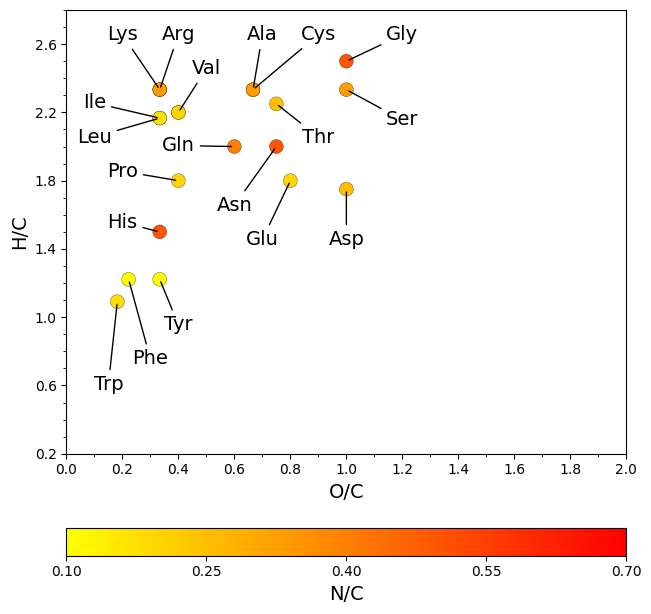

In [41]:
# Plot Amino Acids on Van Krevelen Diagram with N/C Color Coding

fig, ax = plt.subplots(figsize=(6.4, 6), layout='constrained')

# Set up color normalization for N/C ratio
norm_lims = (np.round(aa_df['N/C'].min(), 1), np.round(aa_df['N/C'].max(), 1))
norm = mpl.colors.Normalize(vmin=norm_lims[0], vmax=norm_lims[1])

# Plot amino acids with N/C ratio represented by color
ax_plot = ax.scatter(aa_df['O/C'], aa_df['H/C'], s=100,
                     norm=norm, c=aa_df['N/C'], cmap='autumn_r', edgecolors='k', lw=.2)

# Annotate each amino acid with its 3-letter code
# Positions manually adjusted for clarity and to avoid overlap
combos = [['Lys', (.2, 2.6)],
          ['Arg', (.4, 2.6)],
          ['Ile', (.1, 2.2)],
          ['Leu', (.1, 2)],
          ['Val', (.5, 2.4)],
          ['Cys', (.9, 2.6)],
          ['Ala', (.7, 2.6)],
          ['Thr', (.9, 2)],
          ['Ser', (1.2, 2.1)],
          ['Gln', (.4, 1.95)],
          ['Gly', (1.2, 2.6)],
          ['Asn', (.6, 1.6)],
          ['Glu', (.7, 1.4)],
          ['Asp', (1, 1.4)],
          ['Pro', (.2, 1.8)],
          ['His', (.2, 1.5)],
          ['Tyr', (.4, .9)],
          ['Phe', (.3, .7)],
          ['Trp', (.15, .55)],
          ]
for combo in combos:
    annotate_aa_plot(combo[0], aa_df, ax, (combo[1]))

# Format axes
sfc.set_axis_ticks(overall_df['O/C'].values, ax, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
sfc.set_axis_ticks(overall_df['H/C'].values, ax, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)
ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)

# Add colorbar for N/C ratio
cbar = fig.colorbar(ax_plot, ticks=np.linspace(norm_lims[0], norm_lims[1], 5), location='bottom')
cbar.set_label(label='N/C', size=14)

fig.savefig(f'{save_plots_folder}/amino_acids.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

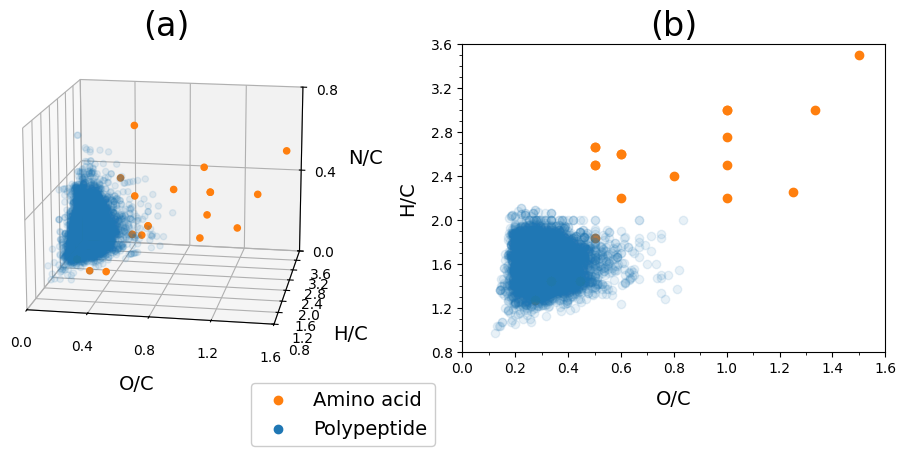

In [42]:
# Compare Amino Acids vs Polypeptides in 3D and 2D

# Create polypeptide dataframe from previously calculated formula list

pdb_df2 = pdb_df.copy()
pdb_df2['type'] = ['Polypeptide']*len(pdb_df2)

aa_df2 = aa_df.copy()
aa_df2['type'] = ['Amino acid']*len(aa_df2)

concat_df = pd.concat((pdb_df2,aa_df2))
concat_df['H'] += 2
concat_df['O'] += 1

concat_df['H/C'] = concat_df['H'] / concat_df['C']
concat_df['O/C'] = concat_df['O'] / concat_df['C']
concat_df['N/C'] = concat_df['N'] / concat_df['C']

fig = plt.figure(figsize=(12, 4))

label_dict = {'Polypeptide': 'tab:blue', 'Amino acid': 'tab:orange'}

# 3D Plot (subplot a)
ax1 = fig.add_subplot(121, projection='3d')

for t in concat_df['type'].unique()[::-1]:
    idx = concat_df['type']==t
    ax1.scatter(concat_df[idx]['O/C'], concat_df[idx]['H/C'], concat_df[idx]['N/C'],
                c=label_dict[t],
                alpha = 0.1 if t == 'Polypeptide' else 1)

# Format 3D axes
sfc.set_axis_ticks(concat_df['O/C'], ax1, axis='x', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1)
sfc.set_axis_ticks(concat_df['H/C'], ax1, axis='y', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1)
sfc.set_axis_ticks(concat_df['N/C'], ax1, axis='z', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1)

ax1.set_xlabel('O/C', fontsize=14, labelpad=8)
ax1.set_ylabel('H/C', fontsize=14, labelpad=10)
ax1.set_zlabel('N/C', fontsize=14, labelpad=10)

ax1.view_init(elev=15, azim=-80)
ax1.set_box_aspect(None, zoom=1.2)
ax1.set_title('(a)', fontsize=24)

# 2D Plot (subplot b)
ax2 = fig.add_subplot(122)

for t in concat_df['type'].unique()[::-1]:
    idx = concat_df['type']==t
    ax2.scatter(concat_df[idx]['O/C'], concat_df[idx]['H/C'],
                c=label_dict[t], alpha = 0.1 if t == 'Polypeptide' else 1)

    ax2.scatter(None,None,label=t,c=label_dict[t])

# Format 2D axes
sfc.set_axis_ticks(concat_df['O/C'].values, ax2, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
sfc.set_axis_ticks(concat_df['H/C'].values, ax2, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

ax2.set_xlabel('O/C', fontsize=14, labelpad=10)
ax2.set_ylabel('H/C', fontsize=14, labelpad=10)

ax2.legend(framealpha=1, bbox_to_anchor=(-.5, -.1), loc='upper left', borderaxespad=0, fontsize=14)
ax2.set_title('(b)', fontsize=24)

fig.savefig(f'{save_plots_folder}/amino_acids_&_peptides.png', dpi=600, facecolor='#fff', bbox_inches='tight')